# WCC Experiments: Gurobi vs Nearest-Neighbour Heuristic

Run the MP-CVRP-P model on multiple instances:
- Small instance (10 cafes)
- Medium instance (15 cafes)
- Full instance (34 cafes)

Then run the nearest-neighbour heuristic on the same instances and compare.

In [1]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import time as time_module
import matplotlib.pyplot as plt

## Load Data

In [2]:
REAL_DIR = '../data/real'
SYNTH_DIR = '../data/synthetic'

# Products
products_df = pd.read_csv(f'{SYNTH_DIR}/products.csv')
P = products_df['product_id'].tolist()
revenue = dict(zip(products_df['product_id'], products_df['revenue_per_unit']))
margin = dict(zip(products_df['product_id'], products_df['margin_per_unit']))
weight = dict(zip(products_df['product_id'], products_df['weight_per_unit_kg']))

# Cafes
cafes_df = pd.read_csv(f'{SYNTH_DIR}/cafes.csv')
all_cafe_ids = cafes_df['cafe_id'].tolist()

# Demands
demands_df = pd.read_csv(f'{SYNTH_DIR}/demands.csv')

# Distance and time matrices
distance_df = pd.read_csv(f'{REAL_DIR}/distance_matrix.csv', index_col=0)
time_df = pd.read_csv(f'{REAL_DIR}/time_matrix.csv', index_col=0)

# Vans
vans_df = pd.read_csv(f'{SYNTH_DIR}/vans.csv')

# Depot
depot_df = pd.read_csv(f'{SYNTH_DIR}/depot.csv')
depot_name = depot_df.loc[0, 'name']

# Perishability
perish_df = pd.read_csv(f'{SYNTH_DIR}/perishability_params.csv')
perish_params = dict(zip(perish_df['parameter'], perish_df['value']))

print(f'Loaded: {len(cafes_df)} cafes, {len(P)} products, {len(vans_df)} vans')
print(f'Depot: {depot_name}')

cafe_id_to_name = dict(zip(cafes_df["cafe_id"], cafes_df["cafe_name"]))
demand_raw = {(row["cafe_id"], row["product_id"]): row["daily_demand"] for _, row in demands_df.iterrows()}
cost = dict(zip(products_df['product_id'], products_df['cost_per_unit']))
w = dict(zip(products_df['product_id'], products_df['weight_per_unit_kg']))
milk_products = products_df.loc[products_df["category"] == "milk", "product_id"].tolist()
Q = dict(zip(vans_df["van_id"], vans_df["capacity_kg"]))
F = dict(zip(vans_df["van_id"], vans_df["fuel_cost_per_km"]))
T_max = float(perish_params["T_max_hours"])
loading_time = float(perish_params["loading_time_minutes"]) / 60.0
service_time = float(perish_params["service_time_minutes"]) / 60.0
beta = 5.0
M_time = 1000

Loaded: 34 cafes, 7 products, 5 vans
Depot: Peter Hall Building UniMelb


## Gurobi Model & Heuristic

In [3]:
def run_experiment(n_cafes_limit, num_vans, time_limit=300):
    # Setup
    cafes_sub = cafes_df["cafe_name"].tolist()[:n_cafes_limit]
    nodes_sub = [depot_name] + cafes_sub
    K_sub = vans_df["van_id"].tolist()[:num_vans]
    A_sub = [(i, j) for i in nodes_sub for j in nodes_sub if i != j]

    d_sub = {}
    for cid, cname in cafe_id_to_name.items():
        if cname in cafes_sub:
            for p in P:
                d_sub[cname, p] = demand_raw.get((cid, p), 0)

    D_sub = {(i,j): float(distance_df.loc[i,j]) for i,j in A_sub}
    T_sub = {(i,j): float(time_df.loc[i,j]) / 60.0 for i,j in A_sub}
    Q_sub = {k: Q[k] for k in K_sub}
    F_sub = {k: F[k] for k in K_sub}
    M_milk_sub = sum(d_sub[i, p] for i in cafes_sub for p in milk_products)
    n_c = len(cafes_sub)

    # Gurobi
    m = gp.Model("vrp")
    m.Params.OutputFlag = 1
    m.Params.TimeLimit = time_limit

    x = m.addVars(A_sub, K_sub, vtype=GRB.BINARY, name="x")
    y = m.addVars(cafes_sub, K_sub, vtype=GRB.BINARY, name="y")
    z = m.addVars(cafes_sub, vtype=GRB.BINARY, name="z")
    q = m.addVars(cafes_sub, P, K_sub, lb=0, vtype=GRB.CONTINUOUS, name="q")
    R = m.addVars(K_sub, lb=0, vtype=GRB.CONTINUOUS, name="R")
    g = m.addVars(K_sub, vtype=GRB.BINARY, name="g")
    u = m.addVars(cafes_sub, K_sub, lb=0, vtype=GRB.CONTINUOUS, name="u")

    m.setObjective(
        gp.quicksum(margin[p] * q[i,p,k] for i in cafes_sub for p in P for k in K_sub)
        - gp.quicksum(F_sub[k] * D_sub[i,j] * x[i,j,k] for (i,j) in A_sub for k in K_sub)
        - gp.quicksum(beta * R[k] for k in K_sub),
        GRB.MAXIMIZE)

    m.addConstrs((gp.quicksum(y[i,k] for k in K_sub) == z[i] for i in cafes_sub), name="serve_once")
    m.addConstrs((gp.quicksum(q[i,p,k] for k in K_sub) == d_sub[i,p] * z[i] for i in cafes_sub for p in P), name="demand")
    m.addConstrs((q[i,p,k] <= d_sub[i,p] * y[i,k] for i in cafes_sub for p in P for k in K_sub), name="link")
    m.addConstrs((gp.quicksum(w[p] * q[i,p,k] for i in cafes_sub for p in P) <= Q_sub[k] for k in K_sub), name="capacity")
    m.addConstrs((gp.quicksum(x[i,j,k] for j in nodes_sub if j!=i) == y[i,k] for i in cafes_sub for k in K_sub), name="flow_out")
    m.addConstrs((gp.quicksum(x[j,i,k] for j in nodes_sub if j!=i) == y[i,k] for i in cafes_sub for k in K_sub), name="flow_in")
    m.addConstrs((gp.quicksum(x[depot_name,j,k] for j in cafes_sub) <= 1 for k in K_sub), name="depot_depart")
    m.addConstrs((gp.quicksum(x[i,depot_name,k] for i in cafes_sub) <= 1 for k in K_sub), name="depot_return")
    m.addConstrs((gp.quicksum(x[depot_name,j,k] for j in cafes_sub) == gp.quicksum(x[i,depot_name,k] for i in cafes_sub) for k in K_sub), name="depot_balance")
    m.addConstrs((u[i,k] - u[j,k] + n_c * x[i,j,k] <= n_c - 1 for i in cafes_sub for j in cafes_sub if i!=j for k in K_sub), name="mtz")
    m.addConstrs((u[i,k] <= n_c * y[i,k] for i in cafes_sub for k in K_sub), name="mtz_upper")
    m.addConstrs((u[i,k] >= y[i,k] for i in cafes_sub for k in K_sub), name="mtz_lower")
    m.addConstrs((R[k] == loading_time * gp.quicksum(x[depot_name,j,k] for j in cafes_sub) + gp.quicksum(T_sub[i,j] * x[i,j,k] for (i,j) in A_sub) + service_time * gp.quicksum(y[i,k] for i in cafes_sub) for k in K_sub), name="route_duration")
    m.addConstrs((gp.quicksum(q[i,p,k] for i in cafes_sub for p in milk_products) <= M_milk_sub * g[k] for k in K_sub), name="milk_indicator")
    m.addConstrs((R[k] <= T_max + M_time * (1 - g[k]) for k in K_sub), name="milk_time_limit")

    m.optimize()

    # Gurobi results
    gur = {'method': 'Gurobi', 'n_cafes': n_c, 'n_vans': num_vans}
    if m.Status in [GRB.OPTIMAL, GRB.TIME_LIMIT] and m.SolCount > 0:
        tot_margin = sum(margin[p] * q[i,p,k].X for i in cafes_sub for p in P for k in K_sub)
        tot_transport = sum(F_sub[k] * D_sub[i,j] * x[i,j,k].X for (i,j) in A_sub for k in K_sub)
        tot_dist = sum(D_sub[i,j] * x[i,j,k].X for (i,j) in A_sub for k in K_sub)
        tot_penalty = sum(beta * R[k].X for k in K_sub)
        gur['profit'] = round(tot_margin - tot_transport - tot_penalty, 2)
        gur['margin'] = round(tot_margin, 2)
        gur['transport'] = round(tot_transport, 2)
        gur['penalty'] = round(tot_penalty, 2)
        gur['distance_km'] = round(tot_dist, 2)
        gur['gap'] = round(m.MIPGap * 100, 2)
        gur['served'] = sum(1 for i in cafes_sub if z[i].X > 0.5)
        gur['solve_time'] = round(m.Runtime, 2)
        routes = []
        for k in K_sub:
            if sum(x[depot_name,j,k].X for j in cafes_sub) > 0.5:
                route = [depot_name]; current = depot_name; visited = set()
                while True:
                    nxts = [j for j in nodes_sub if j != current and j not in visited and x[current,j,k].X > 0.5]
                    if not nxts: break
                    nxt = nxts[0]; route.append(nxt)
                    if nxt == depot_name: break
                    visited.add(nxt); current = nxt
                routes.append(f'{k}: {" -> ".join(route)} ({R[k].X:.2f}h)')
        gur['routes'] = routes
    else:
        gur['profit'] = None; gur['routes'] = []

    # Heuristic
    cafes_sub_df = cafes_df.iloc[:n_cafes_limit]
    cid2name = dict(zip(cafes_sub_df['cafe_id'], cafes_sub_df['cafe_name']))
    dem_sub = demands_df[demands_df['cafe_id'].isin(cafes_sub_df['cafe_id'])].copy()
    dem_sub['cafe_name'] = dem_sub['cafe_id'].map(cid2name)

    cafe_data = {}
    for cname in cafes_sub_df['cafe_name']:
        cdem = dem_sub[dem_sub['cafe_name'] == cname]
        tw = sum(row['daily_demand'] * products_df[products_df['product_id']==row['product_id']].iloc[0]['weight_per_unit_kg'] for _,row in cdem.iterrows())
        tm_ = sum(row['daily_demand'] * products_df[products_df['product_id']==row['product_id']].iloc[0]['margin_per_unit'] for _,row in cdem.iterrows())
        cafe_data[cname] = {'weight': tw, 'revenue': tm_}

    unvisited = set(cafe_data.keys())
    h_routes = []; h_dist = 0; h_cost = 0; h_rev = 0
    for _, van in vans_df.iloc[:num_vans].iterrows():
        cap = van['capacity_kg']; ckm = van['fuel_cost_per_km']
        cur = depot_name; route = [depot_name]; rem = cap
        while True:
            feas = [c for c in unvisited if cafe_data[c]['weight'] <= rem]
            if not feas: break
            nxt = min(feas, key=lambda xx: distance_df.loc[cur, xx])
            dd = distance_df.loc[cur, nxt]
            h_dist += dd; h_cost += dd * ckm; h_rev += cafe_data[nxt]['revenue']
            rem -= cafe_data[nxt]['weight']; route.append(nxt); unvisited.remove(nxt); cur = nxt
        dd = distance_df.loc[cur, depot_name]; h_dist += dd; h_cost += dd * ckm
        route.append(depot_name); h_routes.append(route)

    heur = {
        'method': 'Heuristic', 'n_cafes': n_cafes_limit, 'n_vans': num_vans,
        'profit': round(h_rev - h_cost, 2),
        'margin': round(h_rev, 2),
        'transport': round(h_cost, 2),
        'distance_km': round(h_dist, 2),
        'served': n_cafes_limit - len(unvisited),
        'routes': [' -> '.join(r) for r in h_routes]
    }

    # Print
    print(f'\n{"="*60}')
    print(f'GUROBI  ({n_c}c, {num_vans}v): profit=${gur["profit"]}  dist={gur.get("distance_km")}km  gap={gur.get("gap")}%  served={gur.get("served")}/{n_c}  time={gur.get("solve_time")}s')
    for r in gur['routes']: print(f'  {r}')
    print(f'HEURIST ({n_c}c, {num_vans}v): profit=${heur["profit"]}  dist={heur["distance_km"]}km  served={heur["served"]}/{n_c}')
    for r in heur['routes']: print(f'  {r}')
    print(f'{"="*60}')

    return gur, heur

## Run Experiments

### Small Instance (10 cafes, 2 vans)

In [4]:
g1, h1 = run_experiment(10, 2)

Set parameter Username
Set parameter LicenseID to value 2824592
Academic license - for non-commercial use only - expires 2027-05-20
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 24.6.0 24G624)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 494 rows, 414 columns and 2122 nonzeros (Max)
Model fingerprint: 0xcfc0af87
Model has 362 linear objective coefficients
Variable types: 162 continuous, 252 integer (252 binary)
Coefficient statistics:
  Matrix range     [3e-02, 1e+03]
  Objective range  [4e-01, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]

Found heuristic solution: objective -0.0000000
Presolve removed 216 rows and 154 columns
Presolve time: 0.01s
Presolved: 278 rows, 260 columns, 1916 nonzeros
Variable types: 20 continuous, 240 integer (240 binary

### Medium Instance (15 cafes, 3 vans)

In [5]:
g2, h2 = run_experiment(15, 3)

Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 24.6.0 24G624)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 1266 rows, 1146 columns and 6048 nonzeros (Max)
Model fingerprint: 0x5588f891
Model has 1038 linear objective coefficients
Variable types: 363 continuous, 783 integer (783 binary)
Coefficient statistics:
  Matrix range     [1e-02, 1e+03]
  Objective range  [1e-01, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]

Found heuristic solution: objective -0.0000000
Presolve removed 424 rows and 333 columns
Presolve time: 0.09s
Presolved: 842 rows, 813 columns, 9043 nonzeros
Variable types: 45 continuous, 768 integer (768 binary)

Root relaxation: objective 1.493206e+03, 154 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |  

### Full Instance (34 cafes, 3 vans)

In [6]:
g3, h3 = run_experiment(34, 3)

Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 24.6.0 24G624)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 4781 rows, 4528 columns and 25288 nonzeros (Max)
Model fingerprint: 0xe9ffb631
Model has 4287 linear objective coefficients
Variable types: 819 continuous, 3709 integer (3709 binary)
Coefficient statistics:
  Matrix range     [7e-03, 1e+03]
  Objective range  [8e-02, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]

Found heuristic solution: objective -0.0000000
Presolve removed 955 rows and 751 columns
Presolve time: 0.11s
Presolved: 3826 rows, 3777 columns, 21903 nonzeros
Variable types: 102 continuous, 3675 integer (3675 binary)

Root relaxation: objective 2.887227e+03, 563 iterations, 0.01 seconds (0.02 work units)

    Nodes    |    Current No

### Full Instance (34 cafes, 5 vans)

In [7]:
g4, h4 = run_experiment(34, 5)

Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 24.6.0 24G624)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 7787 rows, 7524 columns and 41980 nonzeros (Max)
Model fingerprint: 0x0f2725ff
Model has 7145 linear objective coefficients
Variable types: 1365 continuous, 6159 integer (6159 binary)
Coefficient statistics:
  Matrix range     [7e-03, 1e+03]
  Objective range  [7e-02, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]

Found heuristic solution: objective -0.0000000
Presolve removed 1433 rows and 1229 columns
Presolve time: 0.20s
Presolved: 6354 rows, 6295 columns, 36505 nonzeros
Variable types: 170 continuous, 6125 integer (6125 binary)

Root relaxation: objective 2.888624e+03, 619 iterations, 0.01 seconds (0.03 work units)

    Nodes    |    Current

## Comparison Summary

In [8]:
experiments = [
    ('Small (10c, 2v)', g1, h1),
    ('Medium (15c, 3v)', g2, h2),
    ('Full (34c, 3v)', g3, h3),
    ('Full (34c, 5v)', g4, h4),
]

rows = []
for name, gur, heur in experiments:
    rows.append({
        'Instance': name,
        'Gurobi Profit ($)': gur.get('profit'),
        'Gurobi Time (s)': gur.get('solve_time'),
        'Gurobi Gap (%)': gur.get('gap'),
        'Gurobi Dist (km)': gur.get('distance_km'),
        'Cafes Served': gur.get('served'),
        'Heuristic Profit ($)': heur.get('profit'),
        'Heuristic Dist (km)': heur.get('distance_km'),
    })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

        Instance  Gurobi Profit ($)  Gurobi Time (s)  Gurobi Gap (%)  Gurobi Dist (km)  Cafes Served  Heuristic Profit ($)  Heuristic Dist (km)
 Small (10c, 2v)            1009.61             0.49            0.00             33.93            10               1016.62                41.72
Medium (15c, 3v)            1486.24           127.22            0.01             35.55            15               1496.03                46.60
  Full (34c, 3v)            2874.08           300.05            0.27             55.13            34               2896.10                66.86
  Full (34c, 5v)            2875.14           300.05            0.29             55.97            34               2896.10                66.86


## Bar Chart

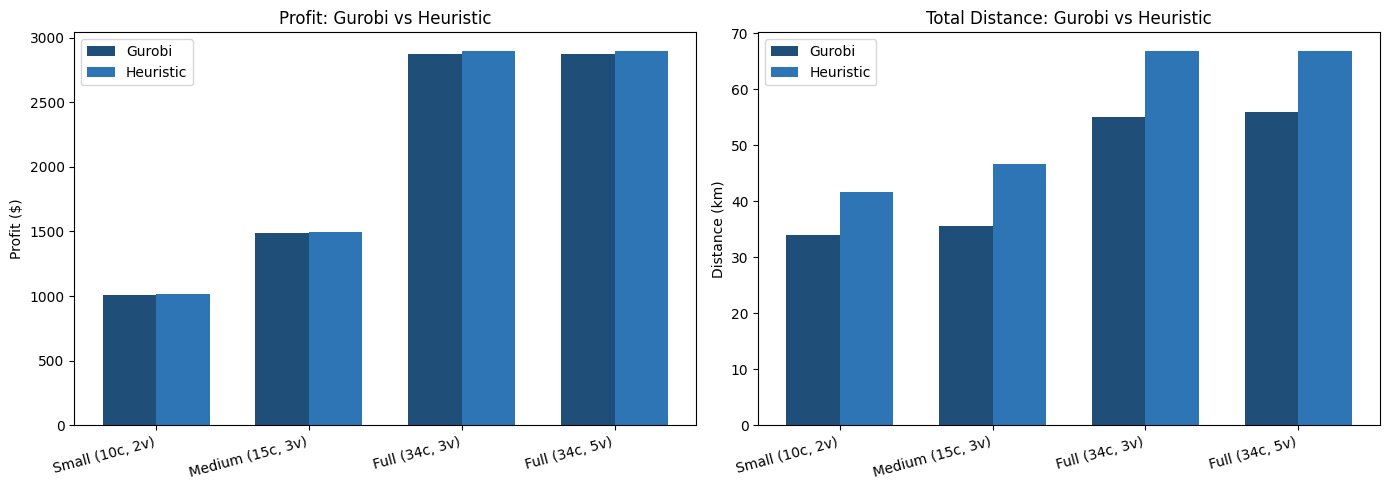

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [name for name, _, _ in experiments]
gurobi_profits = [g.get('profit', 0) or 0 for _, g, _ in experiments]
heur_profits = [h.get('profit', 0) or 0 for _, _, h in experiments]

x_pos = np.arange(len(labels))
width = 0.35

axes[0].bar(x_pos - width/2, gurobi_profits, width, label='Gurobi', color='#1F4E79')
axes[0].bar(x_pos + width/2, heur_profits, width, label='Heuristic', color='#2E75B6')
axes[0].set_ylabel('Profit ($)')
axes[0].set_title('Profit: Gurobi vs Heuristic')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels, rotation=15, ha='right')
axes[0].legend()

gurobi_dists = [g.get('distance_km', 0) or 0 for _, g, _ in experiments]
heur_dists = [h.get('distance_km', 0) or 0 for _, _, h in experiments]

axes[1].bar(x_pos - width/2, gurobi_dists, width, label='Gurobi', color='#1F4E79')
axes[1].bar(x_pos + width/2, heur_dists, width, label='Heuristic', color='#2E75B6')
axes[1].set_ylabel('Distance (km)')
axes[1].set_title('Total Distance: Gurobi vs Heuristic')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, rotation=15, ha='right')
axes[1].legend()

plt.tight_layout()
plt.savefig('../plots/gurobi_vs_heuristic.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Results

In [ ]:
comparison.to_csv('../results/experiment_results.csv', index=False)
print('Results saved to experiment_results.csv')

Results saved to experiment_results.csv
